# Image-to-video dRSA

Loads separate image- and video-session `natraster.mat` files, retains only shared stimulus identities in matching order, aligns the neural responses with sequential model features, and computes image static dRSA and video cross-temporal dRSA.

Set `cfg.use_reliable_channels` to turn the saved image-selectivity reliability filter on or off. The filter is intersected with `good_channels`, and `top_k` is then ranked within the retained pool.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys
import copy
import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.ndimage import gaussian_filter1d

ENV = os.getenv('MY_ENV', 'tiziano_mac_mini')
PROJECT_ROOT = Path('../..').resolve()
with open(PROJECT_ROOT / 'config.yaml', 'r') as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]['paths']
sys.path.extend([paths['src_path'], paths['useful_stuff_path']])

from image_processing.video_feature_extraction import (
    list_video_feature_files, load_aligned_video_features,
)
from project_specific_utils import (
    load_natraster, match_timed_static_movie_rasters, min_max_normalization,
    split_half_filename_suffix,
)
from useful_stuff.general_utils import (
    TimeSeries, create_RDM, dyn_linear_encoding, get_lagplot, get_lagplot_subset,
)
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.II import dynInformationImbalance


In [2]:
@dataclass
class Cfg:
    vid_exp_name: str =  "baby1_260716to24" #    "red_20260720to24" #  
    img_exp_name: str = "baby1_260718to27" #   "red_20260726to27" # 

    # MATLAB channel numbers are one-based and both endpoints are inclusive.
    good_channels: tuple[int, int] | None = (84, 186) #None # None # (101,109) # 
    top_k: int | None = None # 50
    # Intersect good_channels with the image-session reliability config.
    use_reliable_channels: bool = True
    reliable_channels_config: Path | None = None
    reliable_channels_key: str | None = None
    smoothing = 3
    image_crop_ms: int = 1000
    new_fs: float | None = 100  # Set to None to keep the original 1000 Hz.
    normalization: str | None = None  # Supported: None or 'min_max'.
    signal_RDM_metric: str = 'magnitude_diff'
    model_RDM_metric: str = 'cosine_cnt'
    RSA_metric: str = 'spearman'
    video_RSA_metric: str = 'correlation'
    video_lag_analysis_end_ms: float = 2500
    video_max_lag_ms: float = 700
    video_plot_end_ms: float = 3500
    image_2000ms_onset_ms: float = 2000
    image_2250ms_onset_ms: float = 2250
    last_frame_onset_ms: float = 2500
    residual_conditions: tuple[str, ...] = ('2000ms', '2250ms')
    residual_delay_embedding_lags: tuple[int, int] = (-1, 1)
    residual_regression_type: str = 'lr'
    split_half_frame_timings: tuple[str, ...] = (
        'last_frame', '2000ms', '2250ms',
    )
    split_half_results_dir: Path | None = None
    split_half_feature_centering: bool = True
    split_half_use_spearman_brown: bool = True
    split_half_spearman_brown_k: float = 2
    split_half_static_reference_window_ms: tuple[float, float] = (0, 1000)
    model_name: str = 'ijepa_vith14_1k' #"dino_v3_h" #'vjepa2_vitl_fpc64_256'
    model_dataset_name: str = 'static_dynamic'
    model_pooling: str | None = 'mean'
    model_features_dir: Path | None = None
    example_layer = 1
    linewidth=3


cfg = Cfg()
cfg
vid_natraster_mat_path: Path = Path(f"{paths['data_path']}/data") / f'{cfg.vid_exp_name}_natraster_vid.mat'
img_natraster_mat_path: Path = Path(f"{paths['data_path']}/data") / f'{cfg.img_exp_name}_natraster_img.mat'


In [3]:
# The reusable project loader below aligns all static timing conditions with video.


In [4]:
reliable_channels_config = None
reliable_channels_key = None
if cfg.use_reliable_channels:
    reliable_channels_config = (
        cfg.reliable_channels_config
        or PROJECT_ROOT / 'reliable_channels.yaml'
    )
    # The image-session reliability selection is reused for the movie.
    reliable_channels_key = cfg.reliable_channels_key or cfg.img_exp_name
# end if cfg.use_reliable_channels

loaded_vid_rasters, vid_stimulus_names, vid_channel_numbers = load_natraster(
    vid_natraster_mat_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
loaded_img_rasters, img_stimulus_names, img_channel_numbers = load_natraster(
    img_natraster_mat_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
if not np.array_equal(img_channel_numbers, vid_channel_numbers):
    raise ValueError('Image and movie sessions retained different channels.')
# end if channel numbers differ
loaded_channel_numbers = img_channel_numbers


In [5]:
(
    image_rasters,
    video_rasters,
    image_2000ms_rasters,
    image_2250ms_rasters,
    shared_stimuli,
    aligned_names,
) = match_timed_static_movie_rasters(
    loaded_img_rasters, img_stimulus_names,
    loaded_vid_rasters, vid_stimulus_names,
)
image_names = aligned_names['image']
video_names = aligned_names['movie']
print(f'{len(shared_stimuli)} stimuli shared by all four conditions')

# Optionally rank within the range/reliability-filtered channel pool.
if cfg.top_k is not None:
    if cfg.top_k < 1 or cfg.top_k > len(loaded_channel_numbers):
        raise ValueError('top_k must fit inside the retained channel pool.')
    # end if invalid top_k
    channel_scores = video_rasters.max(axis=(1, 2))
    channel_indices = np.argsort(channel_scores)[-cfg.top_k:][::-1]
else:
    channel_indices = slice(None)
# end if cfg.top_k is not None

selected_channel_numbers = loaded_channel_numbers[channel_indices]
image_rasters = image_rasters[channel_indices, :, :]
image_2000ms_rasters = image_2000ms_rasters[channel_indices, :, :]
image_2250ms_rasters = image_2250ms_rasters[channel_indices, :, :]
video_rasters = video_rasters[channel_indices, :, :]
print(f'Selected MATLAB channels: {selected_channel_numbers.tolist()}')

image_ts = TimeSeries(image_rasters, fs=1000)
image_2000ms_ts = TimeSeries(image_2000ms_rasters, fs=1000)
image_2250ms_ts = TimeSeries(image_2250ms_rasters, fs=1000)
video_ts = TimeSeries(video_rasters, fs=1000)

if cfg.new_fs is not None:
    for neural_ts in (image_ts, image_2000ms_ts, image_2250ms_ts, video_ts):
        neural_ts.resample(cfg.new_fs)
    # end for neural_ts
# end if cfg.new_fs is not None

100 stimuli shared by all four conditions
Selected MATLAB channels: [101, 102, 103, 104, 105, 106, 107, 108, 109, 121, 122, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 158, 159, 160, 161, 162, 163, 164, 165]


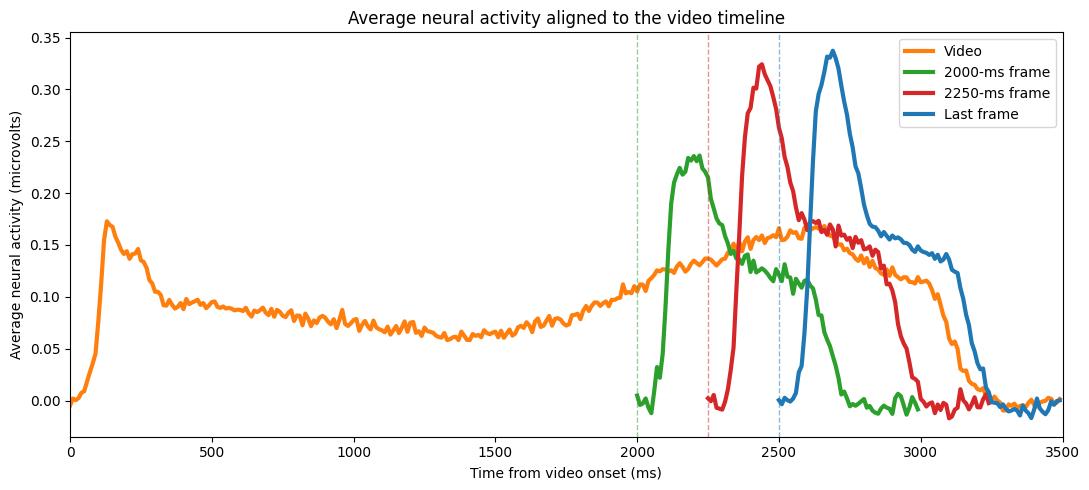

In [6]:
# Average over channels and matched stimuli, preserving the neural time axis.
video_activity = video_ts.get_array().mean(axis=(0, 2))
video_time_ms = np.arange(video_activity.size) * 1000 / video_ts.get_fs()
video_plot_mask = video_time_ms < cfg.video_plot_end_ms

static_conditions = (
    (image_2000ms_ts, cfg.image_2000ms_onset_ms, '2000-ms frame', 'tab:green'),
    (image_2250ms_ts, cfg.image_2250ms_onset_ms, '2250-ms frame', 'tab:red'),
    (image_ts, cfg.last_frame_onset_ms, 'Last frame', 'tab:blue'),
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    video_time_ms[video_plot_mask], video_activity[video_plot_mask],
    color='tab:orange', label='Video', linewidth=cfg.linewidth,
)
for static_ts, onset_ms, label, color in static_conditions:
    static_activity = static_ts.get_array().mean(axis=(0, 2))
    static_time_ms = onset_ms + (
        np.arange(static_activity.size) * 1000 / static_ts.get_fs()
    )
    ax.plot(
        static_time_ms, static_activity, color=color, label=label,
        linewidth=cfg.linewidth,
    )
    ax.axvline(onset_ms, color=color, linestyle='--', linewidth=1, alpha=0.5)
# end for static_ts

ax.set(
    xlim=(0, cfg.video_plot_end_ms),
    xlabel='Time from video onset (ms)',
    ylabel='Average neural activity (microvolts)',
    title='Average neural activity aligned to the video timeline',
)
ax.legend()
fig.tight_layout()


# DNN-dynamics style RSA

In [7]:
# Load all extracted model layers in numeric order (layer 0, 1, ..., 23).
model_features_dir = cfg.model_features_dir or Path(paths['data_path']) / 'models'
feature_paths = list_video_feature_files(
    model_features_dir, cfg.model_name, cfg.model_dataset_name, cfg.model_pooling,
)

# Reuse the shared subset so image and video model RDMs contain identical stimuli.
image_names_all = [Path(name).name for name in image_names]
video_names_all = [Path(name).name for name in video_names]
# Static image analyses use the final frame from the matching video feature set.
image_model_names = video_names_all

image_neural_ts = TimeSeries(
    image_rasters[:, :cfg.image_crop_ms, :], fs=1000,
)
video_neural_ts = TimeSeries(
    video_rasters, fs=1000,
)
if cfg.new_fs is not None:
    image_neural_ts.resample(cfg.new_fs)
    video_neural_ts.resample(cfg.new_fs)
# end if cfg.new_fs is not None

if cfg.normalization == 'min_max':
    # Re-estimate shared bounds using every condition included in the model analyses.
    normalization_reference = np.concatenate([
        image_neural_ts.get_array().reshape(image_neural_ts.shape()[0], -1),
        video_neural_ts.get_array().reshape(video_neural_ts.shape()[0], -1),
    ], axis=1)
    image_neural_ts.set_array(min_max_normalization(
        image_neural_ts.get_array(), reference_data=normalization_reference,
    ))
    video_neural_ts.set_array(min_max_normalization(
        video_neural_ts.get_array(), reference_data=normalization_reference,
    ))
# end if cfg.normalization == 'min_max'

print(f'{len(feature_paths)} model layers')
print(f'{len(image_names_all)} image stimuli aligned to final-frame model features')
print(f'{len(video_names_all)} video stimuli aligned to sequential model features')

32 model layers
100 image stimuli aligned to final-frame model features
100 video stimuli aligned to sequential model features


In [8]:
# Compute the neural image RDM once because it is shared by every model layer.
image_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.RSA_metric,
)

image_drsa.compute_RDM_timeseries(image_ts, 'signal')

image_layer_drsa = []
layer_names = []
for feature_path in feature_paths:
    # The final frame has the same visual content as the corresponding static image.
    final_frame_features, layer_name, _ = load_aligned_video_features(
        feature_path, image_model_names, frame_index=-1,
    )
    model_RDM = create_RDM(final_frame_features, metric=cfg.model_RDM_metric)
    image_drsa.set_RDM(model_RDM, 'model')
    image_layer_drsa.append(image_drsa.compute_static_dRSA().get_array().copy())
    layer_names.append(layer_name)
# end for feature_path

image_layer_drsa = np.stack(image_layer_drsa, axis=0)
print(f'Image static dRSA: {image_layer_drsa.shape} (layers, neural time)')

Image static dRSA: (32, 100) (layers, neural time)


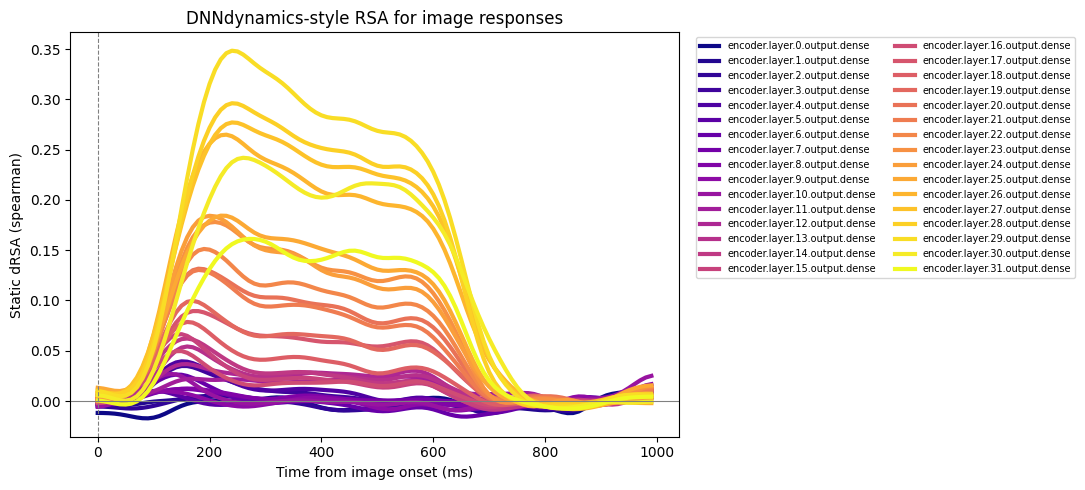

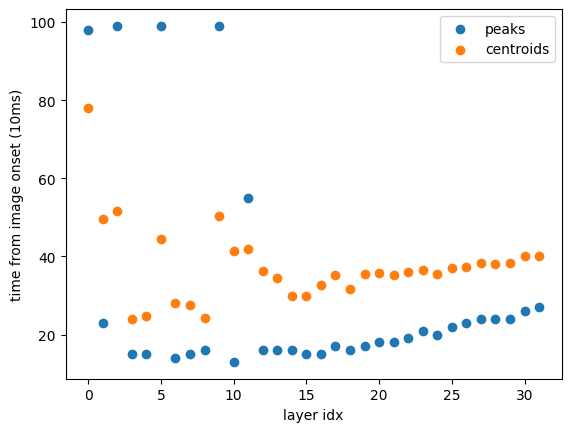

In [9]:
image_time_ms = np.arange(image_layer_drsa.shape[1]) * 1000 / image_neural_ts.get_fs()
layer_colors = plt.cm.plasma(np.linspace(0, 1, len(layer_names)))
tot_centroids = []
tot_peaks = []
fig, ax = plt.subplots(figsize=(11, 5))
for layer_index, (layer_name, layer_drsa) in enumerate(
        zip(layer_names, image_layer_drsa),
        ):
    if cfg.smoothing:
        layer_drsa = gaussian_filter1d(layer_drsa, sigma=cfg.smoothing)
    nonzero_lp = copy.deepcopy(layer_drsa)
    nonzero_lp[nonzero_lp<0] = 0
    normalized_lp = nonzero_lp/np.sum(nonzero_lp)
    centroid = np.dot(normalized_lp, np.arange(len(normalized_lp)))
    tot_centroids.append(centroid)
    tot_peaks.append(np.argmax(normalized_lp))
    ax.plot(
        image_time_ms, layer_drsa, color=layer_colors[layer_index],
        linewidth=cfg.linewidth, label=layer_name,
    )
# end for layer_index
ax.axhline(0, color='grey', linewidth=0.8)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set(xlabel='Time from image onset (ms)',
       ylabel=f'Static dRSA ({cfg.RSA_metric})',
       title=f'DNNdynamics-style RSA for image responses')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=2)
fig.tight_layout()
plt.figure()
plt.scatter(np.arange(len(tot_peaks)), tot_peaks, label="peaks")
plt.scatter(np.arange(len(tot_centroids)), tot_centroids, label="centroids")
plt.ylabel("time from image onset (10ms)")
plt.xlabel("layer idx")
plt.legend()



# Video dRSA
neural video timecourse modelled by frame-wise features


In [10]:
# Compute the neural video RDM once, then replace only the model RDM timecourse.
video_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.video_RSA_metric,
)
video_drsa.compute_RDM_timeseries(video_ts, 'signal')

video_layer_drsa = {}
source_model_fs = None
for feature_path in feature_paths:
    model_features, layer_name, layer_model_fs = load_aligned_video_features(
        feature_path, video_names_all, frame_index=None,
    )

    # Match the model and neural time grids before computing the model RDM timecourse.
    model_ts = TimeSeries(model_features, fs=layer_model_fs)
    model_ts.resample(video_ts.get_fs())
    video_drsa.compute_RDM_timeseries(model_ts, 'model')
    video_layer_drsa[layer_name] = video_drsa.compute_dRSA().copy()

    if source_model_fs is None:
        source_model_fs = layer_model_fs
    elif source_model_fs != layer_model_fs:
        raise ValueError('Model layers have inconsistent source frame rates.')
    # end if source_model_fs is None
# end for feature_path

model_fs = video_neural_ts.get_fs()

example_video_drsa = video_layer_drsa[layer_names[cfg.example_layer]]
neural_time_ms = np.arange(example_video_drsa.shape[0]) * 1000 / video_neural_ts.get_fs()
model_time_ms = np.arange(example_video_drsa.shape[1]) * 1000 / model_fs
print(
    f'{cfg.example_layer} video dRSA: {example_video_drsa.shape} (neural time, model time); '
    f'model features resampled from {source_model_fs:g} to {model_fs:g} Hz'
)

1 video dRSA: (350, 300) (neural time, model time); model features resampled from 60 to 100 Hz


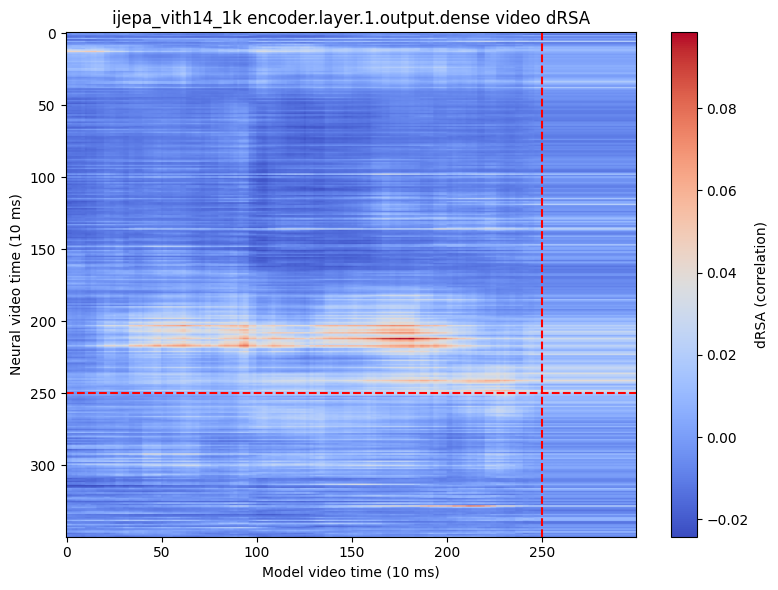

In [11]:
last_frame_ms = cfg.last_frame_onset_ms
last_frame_idx = int(last_frame_ms*cfg.new_fs/1000)
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(
    example_video_drsa, aspect='auto', origin='upper', cmap='coolwarm',
)
ax.axvline(last_frame_idx, linestyle="--", color="red")
ax.axhline(last_frame_idx, linestyle="--", color="red")
ax.set(xlabel='Model video time (10 ms)', ylabel='Neural video time (10 ms)',
       title=f'{cfg.model_name} {layer_names[cfg.example_layer]} video dRSA')
fig.colorbar(image, ax=ax, label=f'dRSA ({cfg.video_RSA_metric})')
fig.tight_layout()

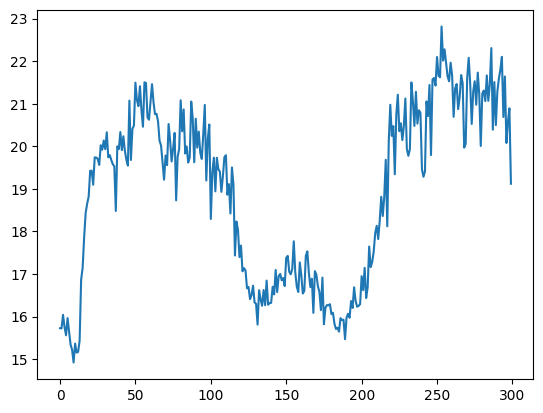

In [12]:
from useful_stuff.general_utils import softmax
diagonals = []
n_layers = np.arange(len(video_layer_drsa.keys()))
T = 0.1
for idx, l in enumerate(layer_names):
    d = np.diag(video_layer_drsa[l], k=0)
    diagonals.append(d)
diagonals = np.array(diagonals)
softmax_lp = []
for t in range(diagonals.shape[1]):
    tpt = softmax(diagonals[:,t], T=T)
    tpt = tpt@n_layers
    softmax_lp.append(tpt)
plt.plot(softmax_lp);

In [13]:
image_layer_drsa.shape

(32, 100)

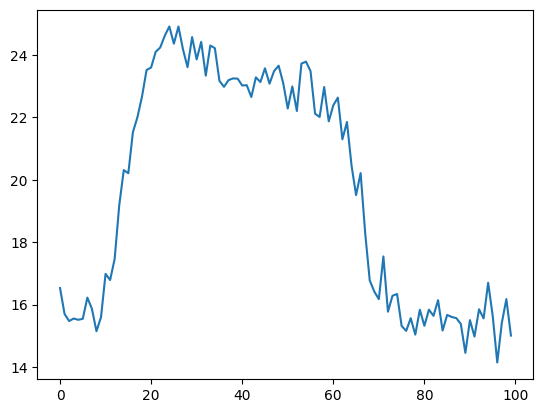

In [14]:
from useful_stuff.general_utils import softmax
diagonals = []
n_layers = np.arange(len(video_layer_drsa.keys()))
T = 0.1
softmax_lp = []
for t in range(image_layer_drsa.shape[1]):
    tpt = softmax(image_layer_drsa[:,t], T=T)
    tpt = tpt@n_layers
    softmax_lp.append(tpt)
plt.plot(softmax_lp);

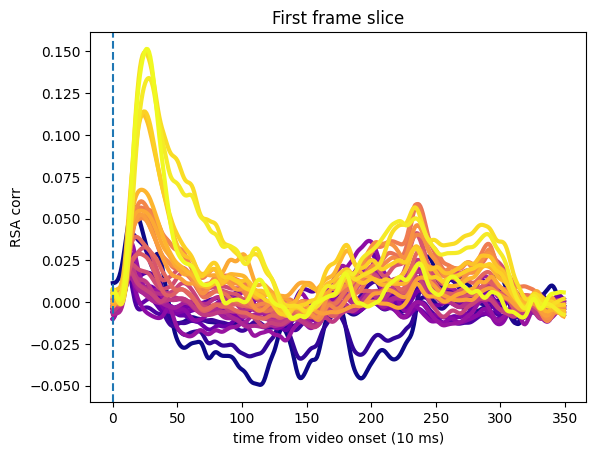

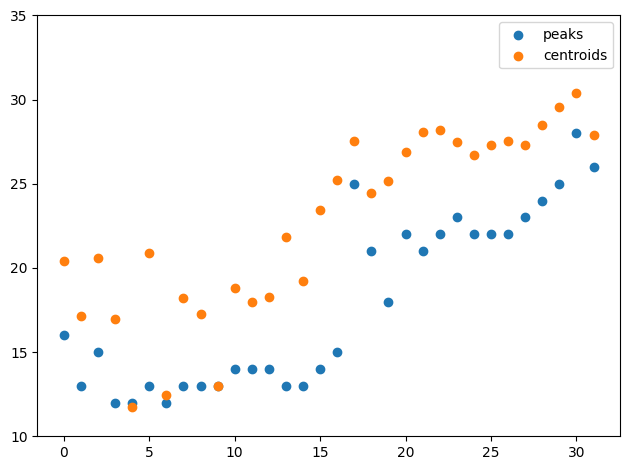

In [15]:
first_frame_ms = 0
beginning_ms, end_ms = 0, 500
beginning_idx, end_idx = int(beginning_ms*cfg.new_fs/1000), int(end_ms*cfg.new_fs/1000)
first_frame_idx = int(first_frame_ms*cfg.new_fs/1000)
tot_centroids = []
tot_peaks = []
window = 7  # smoothing window (samples)
kernel = np.ones(window) / window
# fig, ax = plt.subplots(1,2,figsize=(10,6))
for idx, l in enumerate(layer_names):
    drsa_mat = video_layer_drsa[l]
    if cfg.smoothing:
        lp = gaussian_filter1d(drsa_mat[:,first_frame_idx], sigma=cfg.smoothing)#kernel, mode="same")
    # lp[lp<0] = 0
    nonzero_lp = copy.deepcopy(lp)
    nonzero_lp[nonzero_lp<0] = 0
    normalized_lp = nonzero_lp[beginning_idx:end_idx]/np.sum(nonzero_lp[beginning_idx:end_idx])
    centroid = np.dot(normalized_lp, np.arange(len(normalized_lp)))
    tot_centroids.append(centroid)
    tot_peaks.append(np.argmax(normalized_lp))
    plt.plot(lp, color=layer_colors[idx], linewidth=cfg.linewidth)
plt.axvline(first_frame_idx, linestyle="--")
# ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
plt.ylabel("RSA corr")
plt.xlabel("time from video onset (10 ms)")
plt.title("First frame slice")
plt.figure()
plt.scatter(np.arange(len(tot_centroids)), tot_peaks, label="peaks")
plt.scatter(np.arange(len(tot_centroids)), tot_centroids, label="centroids")
plt.ylim([10, 35])
plt.legend()
plt.tight_layout()

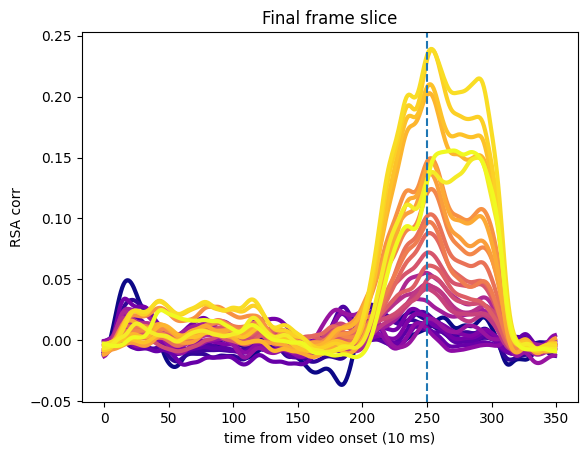

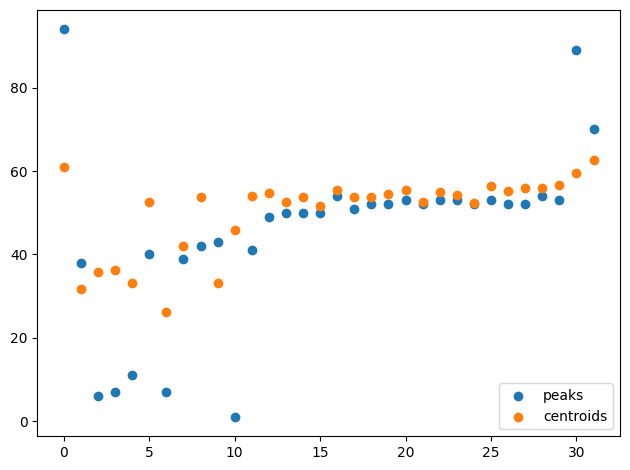

In [16]:
beginning_ms, end_ms = 2000, 3000
beginning_idx, end_idx = int(beginning_ms*cfg.new_fs/1000), int(end_ms*cfg.new_fs/1000)

tot_centroids = []
tot_peaks = []
window = 7  # smoothing window (samples)
kernel = np.ones(window) / window
# fig, ax = plt.subplots(1,2,figsize=(10,6))
for idx, l in enumerate(layer_names):
    drsa_mat = video_layer_drsa[l]
    lp = gaussian_filter1d(drsa_mat[:,last_frame_idx], sigma=4)#kernel, mode="same")
    # lp[lp<0] = 0
    nonzero_lp = copy.deepcopy(lp)
    nonzero_lp[nonzero_lp<0] = 0
    normalized_lp = nonzero_lp[beginning_idx:end_idx]/np.sum(nonzero_lp[beginning_idx:end_idx])
    centroid = np.dot(normalized_lp, np.arange(len(normalized_lp)))
    tot_centroids.append(centroid)
    tot_peaks.append(np.argmax(normalized_lp))
    plt.plot(lp, color=layer_colors[idx], linewidth=cfg.linewidth)
plt.axvline(last_frame_idx, linestyle="--")
# ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
plt.ylabel("RSA corr")
plt.xlabel("time from video onset (10 ms)")
plt.title("Final frame slice")
plt.figure()
plt.scatter(np.arange(len(tot_centroids)), tot_peaks, label="peaks")
plt.scatter(np.arange(len(tot_centroids)), tot_centroids, label="centroids")
# plt.ylim([30,55])
plt.legend()
plt.tight_layout()

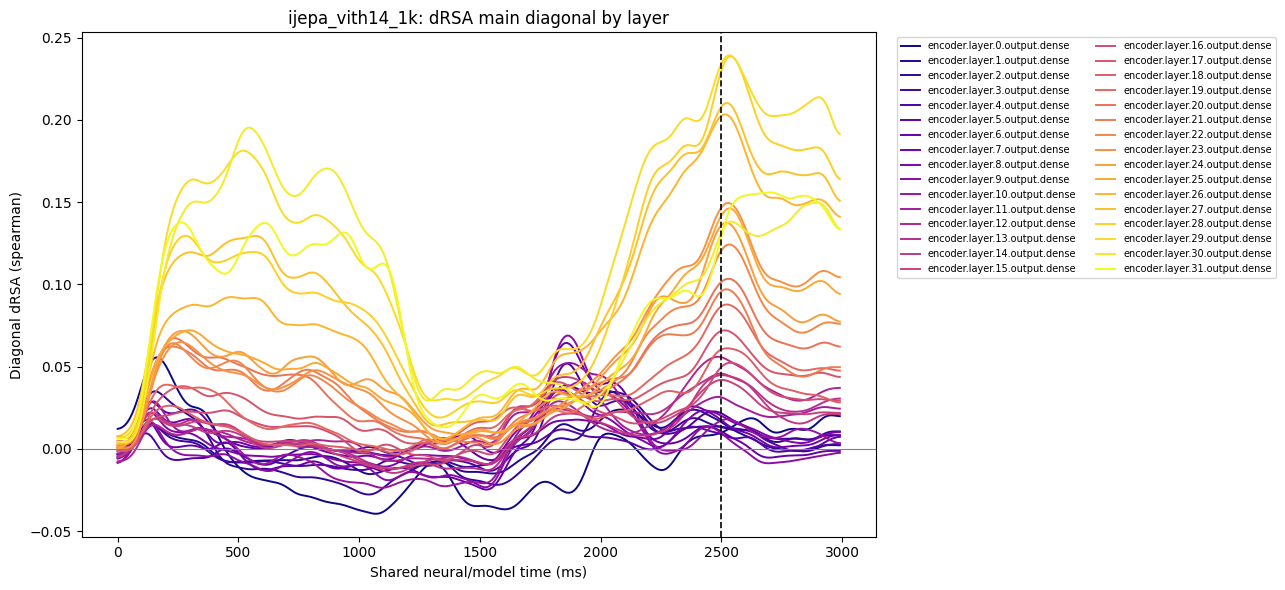

In [17]:
# Extract the main diagonal, where neural time equals model time.
diagonal_fs = video_neural_ts.get_fs()
diagonal_length = min(next(iter(video_layer_drsa.values())).shape)
diagonal_time_ms = np.arange(diagonal_length) * 1000 / diagonal_fs

video_layer_diagonals = []
for layer_name in layer_names:
    layer_diagonal = np.diagonal(video_layer_drsa[layer_name]).copy()
    if layer_diagonal.shape[0] != diagonal_length:
        raise ValueError("dRSA layers have inconsistent diagonal lengths.")
    # end if layer_diagonal.shape[0]
    video_layer_diagonals.append(layer_diagonal)
# end for layer_name
video_layer_diagonals = np.stack(video_layer_diagonals, axis=0)


fig, ax = plt.subplots(figsize=(13, 6))
for layer_index, (layer_name, layer_diagonal) in enumerate(
    zip(layer_names, video_layer_diagonals)
):
    layer_diagonal = gaussian_filter1d(layer_diagonal, sigma=4)
    ax.plot(
        diagonal_time_ms,
        layer_diagonal,
        color=layer_colors[layer_index],
        linewidth=1.4,
        label=layer_name,
    )
# end for layer_index

ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(
    last_frame_ms, color="black", linestyle="--", linewidth=1.2,
)
ax.set(
    xlabel="Shared neural/model time (ms)",
    ylabel=f"Diagonal dRSA ({cfg.RSA_metric})",
    title=f"{cfg.model_name}: dRSA main diagonal by layer",
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=2)
fig.tight_layout()


In [18]:
# max_lag = 50
# beginning_ms, end_ms = 2000, 3000
# beginning_idx, end_idx = int(beginning_ms*cfg.new_fs/1000), int(end_ms*cfg.new_fs/1000)
# lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs
# tot_centroids = []
# tot_peaks = []
# window = 7  # smoothing window (samples)
# kernel = np.ones(window) / window
# # fig, ax = plt.subplots(1,2,figsize=(10,6))
# for idx, l in enumerate(layer_names):
#     drsa_mat = video_layer_drsa[l]
#     lp = get_lagplot_subset(drsa_mat, neural_idx=range(10,100), model_idx=range(10,100), max_lag=max_lag)
#     plt.plot(lags, lp, color=layer_colors[idx], linewidth=cfg.linewidth)
# # ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# # ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
# plt.axvline(0, linestyle="--", color="red")
# plt.ylabel("RSA corr")
# plt.xlabel("time from video onset (ms)")
# plt.title("From 0 to 1000ms")


In [19]:
# max_lag = 50
# beginning_ms, end_ms = 2000, 3000
# beginning_idx, end_idx = int(beginning_ms*cfg.new_fs/1000), int(end_ms*cfg.new_fs/1000)
# lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs

# tot_centroids = []
# tot_peaks = []
# window = 7  # smoothing window (samples)
# kernel = np.ones(window) / window
# # fig, ax = plt.subplots(1,2,figsize=(10,6))
# for idx, l in enumerate(layer_names):
#     drsa_mat = video_layer_drsa[l]
#     lp = get_lagplot_subset(drsa_mat, neural_idx=range(80,250), model_idx=range(80,250), max_lag=max_lag)
#     plt.plot(lags, lp, color=layer_colors[idx], linewidth=cfg.linewidth)
# # ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# # ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
# plt.axvline(0, linestyle="--", color="red")
# plt.ylabel("RSA corr")
# plt.xlabel("lag (ms)")
# plt.title("From 1000 to 2000ms")


In [20]:
# max_lag = 30
# lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs

# tot_centroids = []
# tot_peaks = []
# window = 7  # smoothing window (samples)
# kernel = np.ones(window) / window
# # fig, ax = plt.subplots(1,2,figsize=(10,6))
# for idx, l in enumerate(layer_names):
#     drsa_mat = video_layer_drsa[l]
#     lp = get_lagplot_subset(drsa_mat, neural_idx=range(200,250), model_idx=range(200,250), max_lag=max_lag)
#     plt.plot(lags, lp, color=layer_colors[idx], linewidth=cfg.linewidth)
# # ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# # ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
# plt.axvline(0, linestyle="--", color="red")
# plt.ylabel("RSA corr")
# plt.xlabel("lag (ms)")
# plt.title("From 1000 to 2000ms")


# Raw lagged correlation between image and video neural activity

In [21]:
from useful_stuff.general_utils.utils import mean_centering

# Remove each channel's stimulus-generic response profile (shared across nearly
# every stimulus) so the pattern correlation reflects stimulus-specific content.
video_centered = mean_centering(video_ts.array, axis=2)
image_centered = mean_centering(image_ts.array, axis=2)

running_sum = None
for i in range(video_ts.shape()[2]):
    v = TimeSeries(video_centered[:,:,i], cfg.new_fs)
    i = TimeSeries(image_centered[:,:,i], cfg.new_fs)
    if running_sum is None:
        running_sum = v.lagged_corr(i)
    else:
        running_sum += v.lagged_corr(i)
running_sum = running_sum / video_ts.shape()[2]

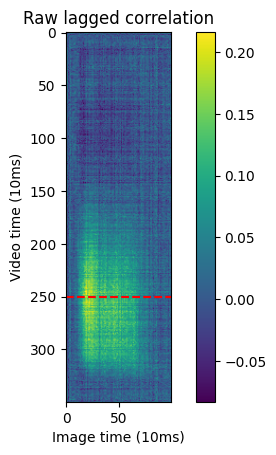

In [22]:
plt.imshow(running_sum)
plt.axhline(last_frame_idx, linestyle="--", color="red")
plt.title("Raw lagged correlation")
plt.xlabel("Image time (10ms)")
plt.ylabel("Video time (10ms)")
plt.colorbar()

In [23]:
from useful_stuff.general_utils.utils import mean_centering
running_sum = None

n = 100
rng = np.random.default_rng(1)

left = rng.permutation(n)
right = rng.permutation(n)

pairs = np.column_stack([left, right])

# Same stimulus-generic centering as the matched-pairing cell above.
video_centered = mean_centering(video_ts.array, axis=2)
image_centered = mean_centering(image_ts.array, axis=2)

for k in range(n):
    v = TimeSeries(video_centered[:,:,pairs[k,0]], cfg.new_fs)
    i = TimeSeries(image_centered[:,:,pairs[k,1]], cfg.new_fs)
    if running_sum is None:
        running_sum = v.lagged_corr(i, metric="correlation")
    else:
        running_sum += v.lagged_corr(i, metric="correlation")
running_sum = running_sum / video_ts.shape()[2]

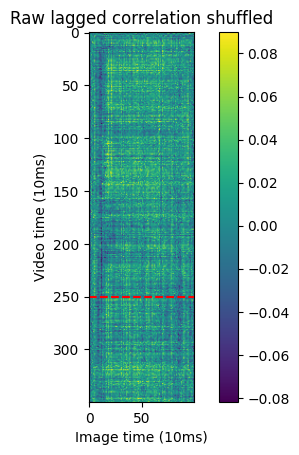

In [24]:
plt.imshow(running_sum)
plt.axhline(last_frame_idx, linestyle="--", color="red")
plt.title("Raw lagged correlation shuffled")
plt.xlabel("Image time (10ms)")
plt.ylabel("Video time (10ms)")
plt.colorbar()

# Image-movie Dynamic RSA

In [25]:
from scipy.spatial.distance import squareform
drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.signal_RDM_metric,
    RSA_metric="correlation",
)
drsa.compute_both_RDM_timeseries(video_ts, image_ts)
# m_ts = []
# for RDM in drsa.signal_RDM_timeseries:
#     m = squareform(RDM)
#     m = m[np.ix_(pairs[:, 0], pairs[:, 0])]   # permute rows and columns
#     m = m[np.triu_indices_from(m, k=1)]       # extract upper triangle
#     m_ts.append(m)
# m_ts = TimeSeries(m_ts, 100)
# drsa.set_RDM_timeseries(m_ts, "signal")
corr_mat = drsa.compute_dRSA()
autocorr_vid, _ = drsa.get_RDM_timeseries("signal").autocorr()
autocorr_img, _ = drsa.get_RDM_timeseries("model").autocorr()


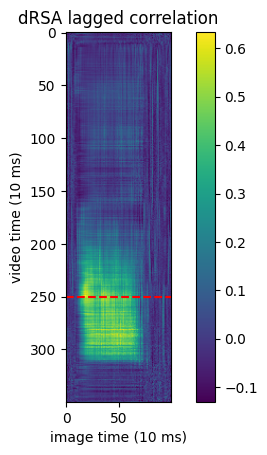

In [26]:
plt.imshow(corr_mat)
plt.ylabel("video time (10 ms)")
plt.xlabel("image time (10 ms)")
plt.axhline(last_frame_idx, linestyle="--", color="red")
plt.title("dRSA lagged correlation")
plt.colorbar()


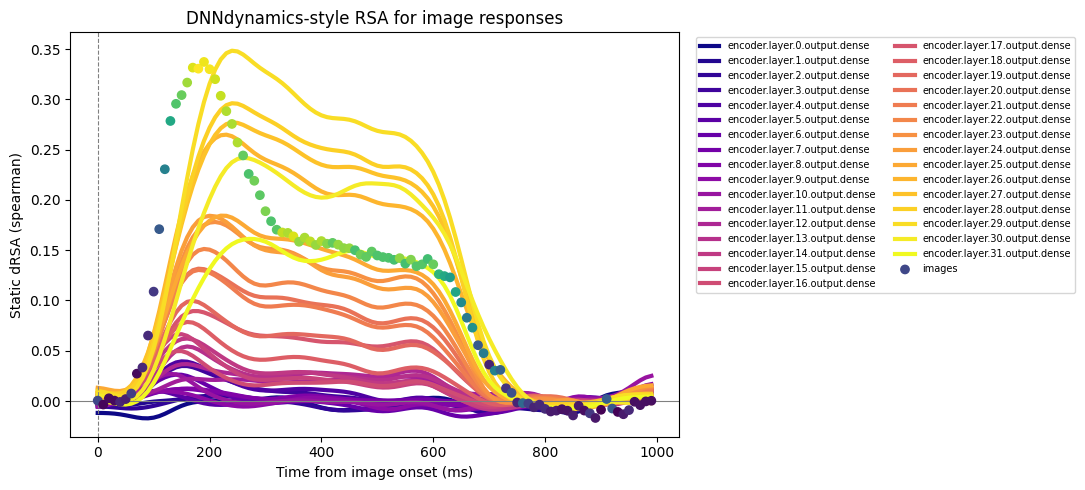

In [27]:
image_time_ms = np.arange(image_layer_drsa.shape[1]) * 1000 / image_neural_ts.get_fs()
layer_colors = plt.cm.plasma(np.linspace(0, 1, len(layer_names)))
tot_centroids = []
tot_peaks = []
fig, ax = plt.subplots(figsize=(11, 5))
for layer_index, (layer_name, layer_drsa) in enumerate(
        zip(layer_names, image_layer_drsa),
        ):
    if cfg.smoothing:
        layer_drsa = gaussian_filter1d(layer_drsa, sigma=cfg.smoothing)
    nonzero_lp = copy.deepcopy(layer_drsa)
    nonzero_lp[nonzero_lp<0] = 0
    normalized_lp = nonzero_lp/np.sum(nonzero_lp)
    centroid = np.dot(normalized_lp, np.arange(len(normalized_lp)))
    tot_centroids.append(centroid)
    tot_peaks.append(np.argmax(normalized_lp))
    ax.plot(
        image_time_ms, layer_drsa, color=layer_colors[layer_index],
        linewidth=cfg.linewidth, label=layer_name,
    )
# end for layer_index
static_to_dynamic_corr = corr_mat[240:260, :].mean(axis=0)
image_trace = np.mean(image_ts.array[:, :, :], axis=(0,2)).T
points = ax.scatter(
    image_time_ms, image_trace,
    c=static_to_dynamic_corr, cmap="viridis", label="images",zorder=5
)
ax.axhline(0, color='grey', linewidth=0.8)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set(xlabel='Time from image onset (ms)',
       ylabel=f'Static dRSA ({cfg.RSA_metric})',
       title=f'DNNdynamics-style RSA for image responses')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=2)
fig.tight_layout()
# ax.colorbar(points, label="dRSA corr (dynamic rows 250:270, avg)")
# plt.legend()

In [28]:
mat, lp = drsa.signal_RDM_timeseries.autocorr()
mat[200:300, 200:300].shape

(100, 100)

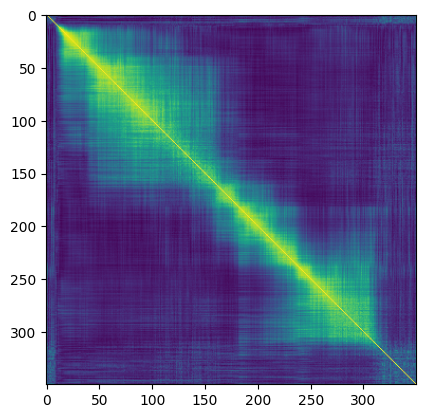

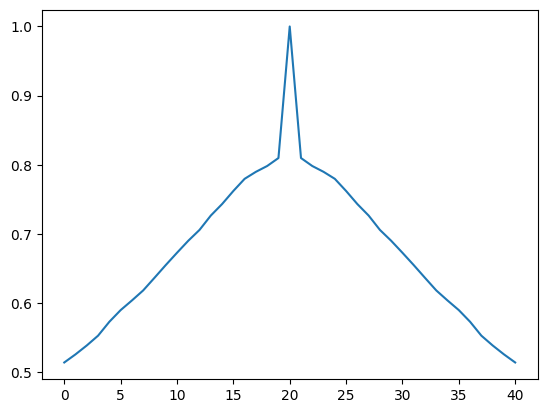

In [29]:
plt.imshow(mat)
plt.figure()
plt.plot(get_lagplot(mat[200:300, 200:300], max_lag=20))

array([[-0.05427112,  0.06502877, -0.04741809, ...,  0.04014242,
         0.0894553 , -0.05901446],
       [-0.05852667,  0.05519341, -0.06601882, ...,  0.07567289,
         0.11361745, -0.01142539],
       [-0.0556915 ,  0.03471921, -0.0687788 , ...,  0.03240232,
         0.06363455, -0.05809212],
       ...,
       [-0.00796645,  0.03766665,  0.02798826, ..., -0.02360072,
        -0.01897041, -0.00045255],
       [ 0.07487405, -0.02411948, -0.03044386, ...,  0.01275991,
        -0.01578357,  0.00659356],
       [-0.02047675,  0.00668413, -0.0006719 , ..., -0.02428998,
        -0.05047801, -0.0164455 ]], shape=(100, 100))

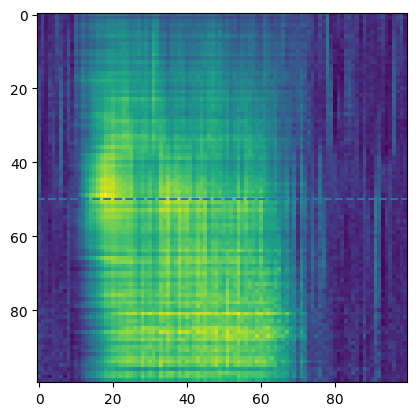

In [30]:
plt.imshow(corr_mat[200:300, :])
plt.axhline(50, linestyle="--")
corr_mat[200:300, :]

Text(0.5, 1.0, 'Static to dynamic lagplot')

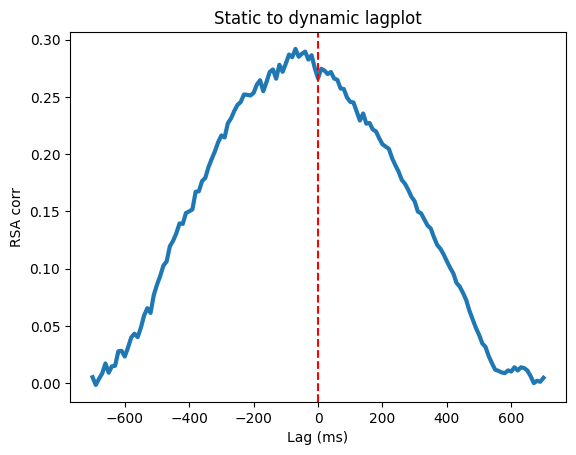

In [31]:
max_lag = 70
lagplot = get_lagplot(corr_mat[250:340, 10:100], max_lag=max_lag)
lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs

plt.plot(lags, lagplot, linewidth=cfg.linewidth)
plt.axvline(0, color="red", linestyle="--")

plt.xlabel("Lag (ms)")
plt.ylabel("RSA corr")
plt.title("Static to dynamic lagplot")


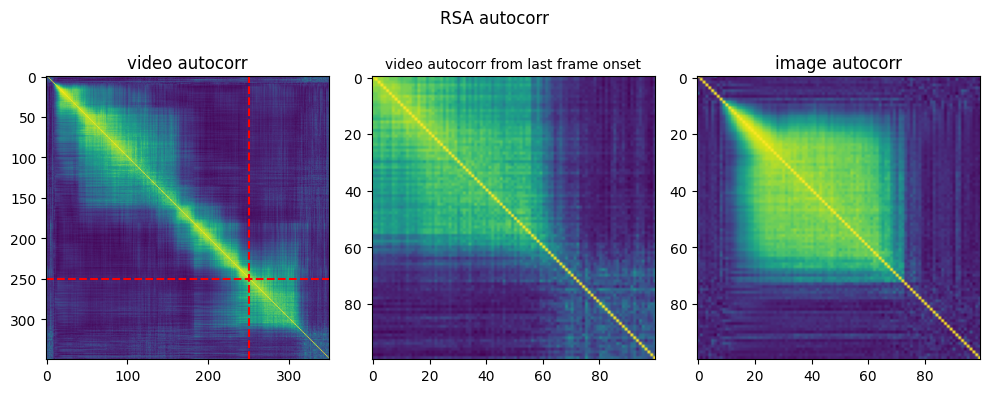

In [32]:
fig, ax = plt.subplots(1,3, figsize=(10,4))

ax[0].imshow(autocorr_vid)
ax[0].set_title("video autocorr")
ax[0].axhline(last_frame_idx, linestyle="--", color="red")
ax[0].axvline(last_frame_idx, linestyle="--", color="red")
ax[1].imshow(autocorr_vid[last_frame_idx:, last_frame_idx:])
ax[1].set_title("video autocorr from last frame onset", fontsize=10)
ax[2].imshow(autocorr_img)
ax[2].set_title("image autocorr")
fig.suptitle("RSA autocorr")
fig.tight_layout()

In [33]:
drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.signal_RDM_metric,
    RSA_metric="correlation",
)
delay_emb_video_ts = video_ts.delay_embeddings(lags=(-5, 5), pad_mode="edge")
delay_emb_image_ts = image_ts.delay_embeddings(lags=(-5, 5), pad_mode="edge")
drsa.compute_both_RDM_timeseries(delay_emb_video_ts, delay_emb_image_ts)
corr_mat = drsa.compute_dRSA()
autocorr_vid, _ = drsa.get_RDM_timeseries("signal").autocorr()
autocorr_img, _ = drsa.get_RDM_timeseries("model").autocorr()


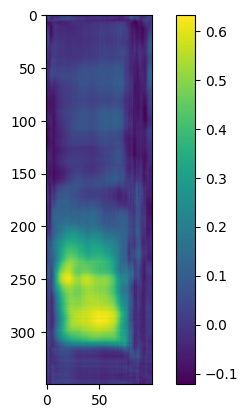

In [34]:
plt.imshow(corr_mat)
plt.colorbar()

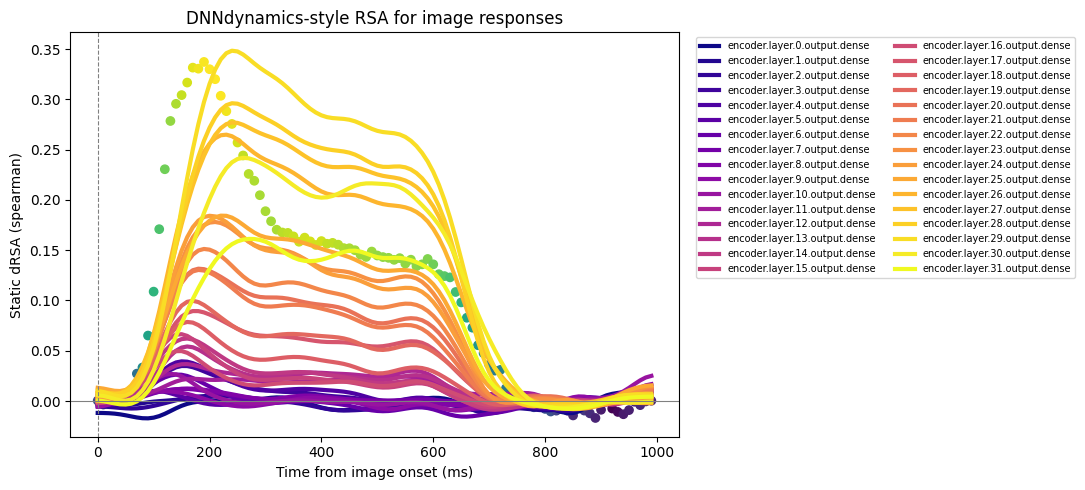

In [35]:
image_time_ms = np.arange(image_layer_drsa.shape[1]) * 1000 / image_neural_ts.get_fs()
layer_colors = plt.cm.plasma(np.linspace(0, 1, len(layer_names)))
tot_centroids = []
tot_peaks = []
fig, ax = plt.subplots(figsize=(11, 5))
for layer_index, (layer_name, layer_drsa) in enumerate(
        zip(layer_names, image_layer_drsa),
        ):
    if cfg.smoothing:
        layer_drsa = gaussian_filter1d(layer_drsa, sigma=cfg.smoothing)
    nonzero_lp = copy.deepcopy(layer_drsa)
    nonzero_lp[nonzero_lp<0] = 0
    normalized_lp = nonzero_lp/np.sum(nonzero_lp)
    centroid = np.dot(normalized_lp, np.arange(len(normalized_lp)))
    tot_centroids.append(centroid)
    tot_peaks.append(np.argmax(normalized_lp))
    ax.plot(
        image_time_ms, layer_drsa, color=layer_colors[layer_index],
        linewidth=cfg.linewidth, label=layer_name,
    )
# end for layer_index
ax.axhline(0, color='grey', linewidth=0.8)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set(xlabel='Time from image onset (ms)',
       ylabel=f'Static dRSA ({cfg.RSA_metric})',
       title=f'DNNdynamics-style RSA for image responses')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=2)
fig.tight_layout()
static_to_dynamic_corr = corr_mat[240:260, :].mean(axis=0)
image_trace = np.mean(image_ts.array[:, :, :], axis=(0,2)).T
points = ax.scatter(
    image_time_ms, image_trace,
    c=static_to_dynamic_corr, cmap="viridis", label="images",
)
# ax.colorbar(points, label="dRSA corr (dynamic rows 250:270, avg)")
# plt.legend()

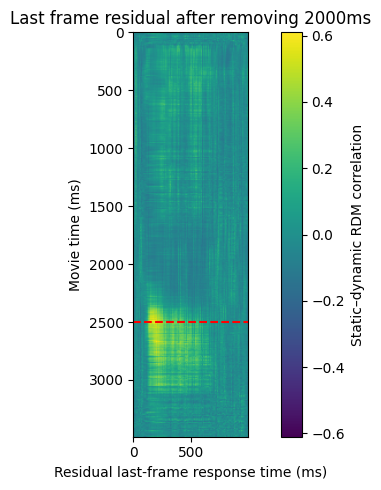

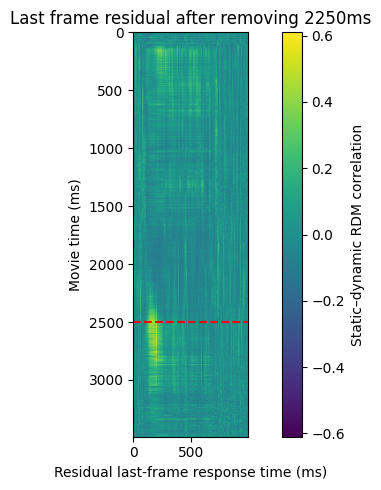

In [36]:
# Remove each earlier static response from the time-resolved last-frame response.
delayed_static_by_condition = {
    '2000ms': image_2000ms_ts,
    '2250ms': image_2250ms_ts,
}
target_array = image_ts.get_array()
target_shape = target_array.shape
residual_similarity_by_condition = {}

for delayed_condition in cfg.residual_conditions:
    if delayed_condition not in delayed_static_by_condition:
        raise ValueError(
            f'Unsupported residual condition: {delayed_condition!r}.'
        )
    # end if delayed_condition

    delayed_ts = delayed_static_by_condition[delayed_condition]
    if delayed_ts.get_fs() != image_ts.get_fs():
        raise ValueError('Static responses have different sampling rates.')
    # end if delayed_ts.get_fs()

    # Embed adjacent delayed-condition samples while keeping stimuli independent.
    predictor_array = delayed_ts.delay_embeddings(
        lags=cfg.residual_delay_embedding_lags, pad_mode='edge',
    ).get_array()
    predictor_flat_ts = TimeSeries(
        predictor_array.reshape(predictor_array.shape[0], -1),
        fs=image_ts.get_fs(),
    )
    target_flat_ts = TimeSeries(
        target_array.reshape(target_shape[0], -1), fs=image_ts.get_fs(),
    )
    regression_model = dyn_linear_encoding(
        regression_type=cfg.residual_regression_type,
        cv_type='same', max_lag=0,
    )
    residual_flat_ts = regression_model.pointwise_regress_out(
        predictor_flat_ts, target_flat_ts,
    )
    residual_static_ts = TimeSeries(
        residual_flat_ts.get_array().reshape(target_shape),
        fs=image_ts.get_fs(),
    )

    residual_drsa = dRSA(
        signal_RDM_metric=cfg.signal_RDM_metric,
        model_RDM_metric=cfg.signal_RDM_metric,
        RSA_metric='correlation',
    )
    residual_drsa.compute_both_RDM_timeseries(video_ts, residual_static_ts)
    residual_similarity_by_condition[delayed_condition] = (
        residual_drsa.compute_dRSA()
    )
# end for delayed_condition

static_time_ms = np.arange(len(image_ts)) * 1000 / image_ts.get_fs()
dynamic_time_ms = np.arange(len(video_ts)) * 1000 / video_ts.get_fs()
similarity_limit = np.nanmax(np.abs(np.stack(
    list(residual_similarity_by_condition.values()), axis=0,
)))
for delayed_condition in cfg.residual_conditions:
    figure, axis = plt.subplots(figsize=(7, 5))
    image = axis.imshow(
        residual_similarity_by_condition[delayed_condition],
        origin='upper', cmap='viridis',
        vmin=-similarity_limit, vmax=similarity_limit,
        extent=(
            static_time_ms[0], static_time_ms[-1],
            dynamic_time_ms[-1], dynamic_time_ms[0],
        ),
    )
    axis.set(
        title=f'Last frame residual after removing {delayed_condition}',
        xlabel='Residual last-frame response time (ms)',
        ylabel='Movie time (ms)',
    )
    figure.colorbar(
        image, ax=axis, label='Static–dynamic RDM correlation',
    )
    axis.axhline(last_frame_idx*10, linestyle="--", color="red")
    figure.tight_layout()
# end for delayed_condition


Loaded split-half results from /Users/tizianocausin/Desktop/static_dynamic/results/static_dynamic_all_frame_timings/baby1_260716to24_vs_baby1_260718to27/reliable_channels_84to186


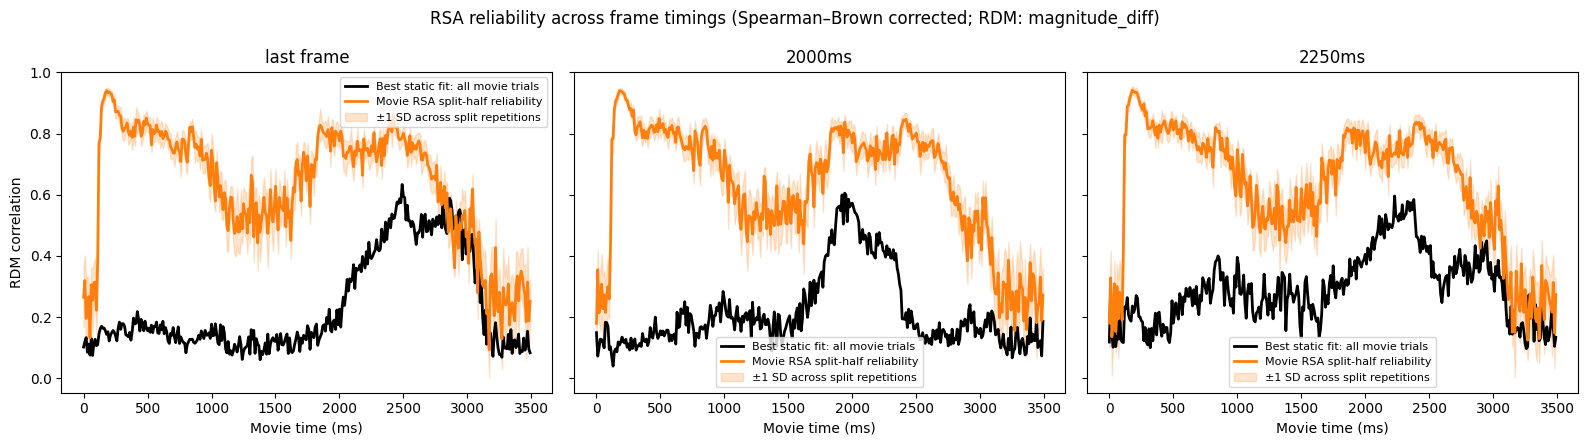

In [37]:
# Resolve the saved split-half results for the active experiment and channels.
if cfg.split_half_results_dir is not None:
    split_half_results_dir = Path(cfg.split_half_results_dir).expanduser()
else:
    split_half_results_root = (
        PROJECT_ROOT / 'results' / 'static_dynamic_all_frame_timings'
        / f'{cfg.vid_exp_name}_vs_{cfg.img_exp_name}'
    )
    if cfg.use_reliable_channels:
        channel_selection = 'reliable_channels'
        if cfg.good_channels is not None:
            first_channel, last_channel = cfg.good_channels
            channel_selection += f'_{first_channel}to{last_channel}'
        # end if cfg.good_channels is not None
        if cfg.top_k is not None:
            channel_selection += f'_top_{cfg.top_k}'
        # end if cfg.top_k is not None
    elif cfg.good_channels is not None:
        first_channel, last_channel = cfg.good_channels
        channel_selection = f'channels_{first_channel}to{last_channel}'
    elif cfg.top_k is not None:
        channel_selection = f'top_{cfg.top_k}'
    else:
        channel_selection = 'all_channels'
    # end if cfg.use_reliable_channels

    channel_results_dir = split_half_results_root / channel_selection
    if cfg.use_reliable_channels and not channel_results_dir.is_dir():
        raise FileNotFoundError(
            'Missing reliable-channel split-half results: '
            f'{channel_results_dir}'
        )
    # end if reliable split-half results are missing
    split_half_results_dir = (
        channel_results_dir
        if channel_results_dir.is_dir()
        else split_half_results_root
    )
# end if cfg.split_half_results_dir is not None

filename_suffix = split_half_filename_suffix(
    cfg.signal_RDM_metric, cfg.split_half_feature_centering,
)
reliability_results_by_timing = {}
for frame_timing in cfg.split_half_frame_timings:
    result_path = (
        split_half_results_dir
        / f'{frame_timing}{filename_suffix}_results.npz'
    )
    if not result_path.is_file():
        raise FileNotFoundError(f'Missing split-half result: {result_path}')
    # end if not result_path.is_file()
    with np.load(result_path, allow_pickle=False) as archive:
        reliability_results_by_timing[frame_timing] = {
            result_name: archive[result_name]
            for result_name in archive.files
        }
    # end with np.load
    saved_rdm_metric = str(
        reliability_results_by_timing[frame_timing]['rdm_metric'].item()
    )
    if saved_rdm_metric != cfg.signal_RDM_metric:
        raise ValueError(
            f'Expected RDM metric {cfg.signal_RDM_metric!r}, but ' 
            f'{result_path} contains {saved_rdm_metric!r}.'
        )
    # end if saved_rdm_metric
# end for frame_timing

correction_suffix = (
    'spearman_brown'
    if cfg.split_half_use_spearman_brown
    else 'uncorrected'
)
correction_label = (
    'Spearman–Brown corrected'
    if cfg.split_half_use_spearman_brown
    else 'uncorrected'
)
figure, axes = plt.subplots(
    1, len(cfg.split_half_frame_timings), figsize=(16, 4.5),
    sharex=True, sharey=True,
)
for axis, frame_timing in zip(axes, cfg.split_half_frame_timings):
    results = reliability_results_by_timing[frame_timing]
    static_times_ms = results['static_times_ms']
    dynamic_times_ms = results['dynamic_times_ms']
    start_ms, end_ms = cfg.split_half_static_reference_window_ms
    static_reference = (
        (static_times_ms >= start_ms) & (static_times_ms <= end_ms)
    )
    if not static_reference.any():
        raise ValueError('The static reference window contains no samples.')
    # end if not static_reference.any()

    # Black: all movie trials. Orange: movie RDM split-half reliability.
    best_static_dynamic_rsa = np.nanmax(
        results['rsa_lagged_correlation_all_dynamic_trials'][
            :, static_reference
        ],
        axis=1,
    )
    dynamic_rsa_reliability = results[
        f'dynamic_rsa_self_consistency_mean_{correction_suffix}'
    ]
    reliability_std_key = (
        f'dynamic_rsa_self_consistency_std_{correction_suffix}'
    )
    if reliability_std_key in results:
        dynamic_rsa_std = results[reliability_std_key]
    else:
        # Older archives retain the split repetitions but not their SD.
        dynamic_rsa_splits = results[
            'dynamic_rsa_self_consistency_splits_uncorrected'
        ]
        if cfg.split_half_use_spearman_brown:
            correction_k = cfg.split_half_spearman_brown_k
            dynamic_rsa_splits = (
                correction_k * dynamic_rsa_splits
                / (1 + (correction_k - 1) * dynamic_rsa_splits)
            )
        # end if cfg.split_half_use_spearman_brown
        dynamic_rsa_std = np.nanstd(dynamic_rsa_splits, axis=0)
    # end if reliability_std_key in results
    axis.plot(
        dynamic_times_ms, best_static_dynamic_rsa,
        color='black', linewidth=2,
        label='Best static fit: all movie trials',
    )
    axis.plot(
        dynamic_times_ms, dynamic_rsa_reliability,
        color='tab:orange', linewidth=2,
        label='Movie RSA split-half reliability',
    )
    axis.fill_between(
        dynamic_times_ms,
        dynamic_rsa_reliability - dynamic_rsa_std,
        dynamic_rsa_reliability + dynamic_rsa_std,
        color='tab:orange', alpha=0.2,
        label='±1 SD across split repetitions',
    )
    axis.set(
        title=frame_timing.replace('_', ' '),
        xlabel='Movie time (ms)',
    )
    axis.legend(fontsize=8)
# end for axis, frame_timing
axes[0].set_ylabel('RDM correlation')
figure.suptitle(
    f'RSA reliability across frame timings ({correction_label}; '
    f'RDM: {cfg.signal_RDM_metric})'
)
figure.tight_layout()
print(f'Loaded split-half results from {split_half_results_dir}')
